In [1]:
import warnings
warnings.filterwarnings('ignore')
from yfinance import download, Ticker

In [2]:
ativos_celulose = {
    "SUZB3.SA": {
        "empresa": "Suzano S.A.",
        "setor": "Celulose e papel",
        "producao": "Celulose de eucalipto BEKP, papel e celulose fluff",
        "mercado": "B3 Brasil"
    },
    "SUZ": {
        "empresa": "Suzano S.A. ADR",
        "setor": "Celulose e papel",
        "producao": "Celulose de eucalipto BEKP e especialidades",
        "mercado": "NYSE Estados Unidos ADR"
    },
    "KLBN11.SA": {
        "empresa": "Klabin S.A.",
        "setor": "Papel e embalagens / Celulose",
        "producao": "Celulose hardwood e softwood, papel kraft, kraftliner e papel cartão",
        "mercado": "B3 Brasil"
    },
    "IP": {
        "empresa": "International Paper Company",
        "setor": "Papel e embalagens",
        "producao": "Celulose para uso interno, papelão ondulado e embalagens à base de fibra",
        "mercado": "NYSE Estados Unidos"
    },
    "SLVM": {
        "empresa": "Sylvamo Corporation",
        "setor": "Papel e celulose",
        "producao": "Papel não revestido e market pulp",
        "mercado": "NYSE Estados Unidos"
    },
    "MERC": {
        "empresa": "Mercer International Inc.",
        "setor": "Celulose e produtos florestais",
        "producao": "Kraft pulp NBSK e NBHK, produtos de madeira",
        "mercado": "NASDAQ Estados Unidos"
    },
    "UPM.HE": {
        "empresa": "UPM-Kymmene Oyj",
        "setor": "Celulose e bioprodutos",
        "producao": "Celulose softwood e hardwood, papéis especiais e bioenergia",
        "mercado": "Nasdaq Helsinki Finlândia"
    },
    "STEAV.HE": {
        "empresa": "Stora Enso Oyj",
        "setor": "Produtos florestais e biomateriais",
        "producao": "Celulose, embalagens à base de fibra, madeira e biomateriais",
        "mercado": "Nasdaq Helsinki Finlândia"
    },
    "SCA-B.ST": {
        "empresa": "Svenska Cellulosa Aktiebolaget SCA",
        "setor": "Produtos florestais e celulose",
        "producao": "Celulose, madeira, papel e produtos de higiene",
        "mercado": "Nasdaq Stockholm Suécia"
    },
    "CLW": {
        "empresa": "Clearwater Paper Corporation",
        "setor": "Papel e papelboard",
        "producao": "Papelboard branqueado e celulose para uso próprio",
        "mercado": "NYSE Estados Unidos"
    }
}


In [3]:
tickers = ['SUZB3.SA', 'IP', 'SLVM', 'MERC', 'UPM.HE', 'STEAV.HE', 'SCA-B.ST', 'CLW'] # 'KLBN11.SA'
df = download(tickers, period='10y', interval="1mo", auto_adjust=False)

df = df[
    ~(
        (df["Open"] == df["Close"]) &
        (df["High"] == df["Low"]) &
        (df["Volume"] == 0)
    )
]

[*********************100%***********************]  8 of 8 completed


In [4]:
# normalização dos preços

df_norm = df.get('Adj Close').copy()

for col in df_norm.columns:
    serie = df_norm[col]

    base = serie.dropna()
    if len(base) < 2:
        continue

    df_norm[col] = serie / base.iloc[0]

df_norm

Ticker,CLW,IP,MERC,SCA-B.ST,SLVM,STEAV.HE,SUZB3.SA,UPM.HE
Date,,,,,,,,
2016-02-01,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,NaN,1.000000
2016-03-01,1.192771,1.164309,1.038462,0.988313,NaN,1.096837,NaN,1.017253
2016-04-01,1.468896,1.227575,0.935471,0.985197,NaN,1.107811,NaN,1.065815
2016-05-01,1.539464,1.196084,1.003404,1.167602,NaN,1.136049,NaN,1.163186
2016-06-01,1.607327,1.215235,0.888697,1.176348,NaN,1.071706,NaN,1.103311
...,...,...,...,...,...,...,...,...
2025-09-01,0.510450,2.084987,0.455728,3.338998,1.704682,1.601969,3.277784,2.317942
2025-10-01,0.433981,1.736291,0.332302,3.403442,1.565131,1.762919,3.211440,2.318939
2025-11-01,0.447258,1.774036,0.286413,3.293350,1.844644,1.754402,3.125390,2.418951


In [5]:
import plotly.express as px
fig = px.line(df_norm,x=df_norm.index,y=df_norm.columns)
fig.update_layout(template="plotly_white", width=1200, height=700)
fig.show()

In [6]:
import yfinance as yf
import pandas as pd

# Market cap (capitalização de mercado) é o valor de mercado total de uma empresa na bolsa em um determinado momento.
# MarketCap = Preço da ação x Número de ações em circulação

dados = []
for t in tickers:
    info = yf.Ticker(t).info
    dados.append({
        "ticker": t,
        "market_cap": info.get("marketCap")
    })

df_cap = pd.DataFrame(dados).dropna()

df_cap["peso"] = df_cap["market_cap"] / df_cap["market_cap"].sum()
df_cap

,ticker,market_cap,peso
0,SUZB3.SA,64106586112,0.327380
1,IP,21253541888,0.108538
2,SLVM,1929000704,0.009851
3,MERC,131285720,0.000670
4,UPM.HE,13256926208,0.067701
5,STEAV.HE,8556527104,0.043697
6,SCA-B.ST,86298296320,0.440708
7,CLW,285043360,0.001456


In [7]:
retornos = df['Close'].pct_change(1)
pesos = df_cap.set_index("ticker")["peso"]


In [8]:
retornos

Ticker,CLW,IP,MERC,SCA-B.ST,SLVM,STEAV.HE,SUZB3.SA,UPM.HE
Date,,,,,,,,
2016-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01,0.192771,0.149580,0.038461,-0.011687,NaN,0.096837,NaN,0.017252
2016-04-01,0.231499,0.054337,-0.111111,-0.003153,NaN,0.010006,NaN,0.047739
2016-05-01,0.048041,-0.025653,0.072619,0.055753,NaN,-0.012238,NaN,0.036571
2016-06-01,0.044082,0.005218,-0.114317,0.007491,NaN,-0.056637,NaN,-0.051475
...,...,...,...,...,...,...,...,...
2025-09-01,-0.037552,-0.066023,-0.135135,-0.033800,-0.041405,-0.101887,-0.048618,-0.043568
2025-10-01,-0.149807,-0.167241,-0.270833,0.019300,-0.081863,0.087185,-0.020241,0.000430
2025-11-01,0.030595,0.021739,-0.138095,-0.032347,0.166749,-0.004831,-0.026795,0.009880


In [9]:
pesos

ticker
SUZB3.SA    0.327380
IP          0.108538
SLVM        0.009851
MERC        0.000670
UPM.HE      0.067701
STEAV.HE    0.043697
SCA-B.ST    0.440708
CLW         0.001456
Name: peso, dtype: float64

In [10]:
retorno_indice = (retornos * pesos).sum(axis=1)
serie_indice = retorno_indice.cumsum()

serie_indice

Date
2016-02-01    0.000000
2016-03-01    0.016790
2016-04-01    0.025230
2016-05-01    0.049076
2016-06-01    0.046972
                ...   
2025-09-01    1.157761
2025-10-01    1.144121
2025-11-01    1.125505
2025-12-01    1.157039
2026-01-01    1.164698
Freq: MS, Length: 120, dtype: float64

In [11]:
import numpy as np
x = np.arange(len(serie_indice))
y = serie_indice.values
coef = np.polyfit(x, y, 1)
y_reg = coef[0] * x + coef[1]

In [12]:
serie_indice

Date
2016-02-01    0.000000
2016-03-01    0.016790
2016-04-01    0.025230
2016-05-01    0.049076
2016-06-01    0.046972
                ...   
2025-09-01    1.157761
2025-10-01    1.144121
2025-11-01    1.125505
2025-12-01    1.157039
2026-01-01    1.164698
Freq: MS, Length: 120, dtype: float64

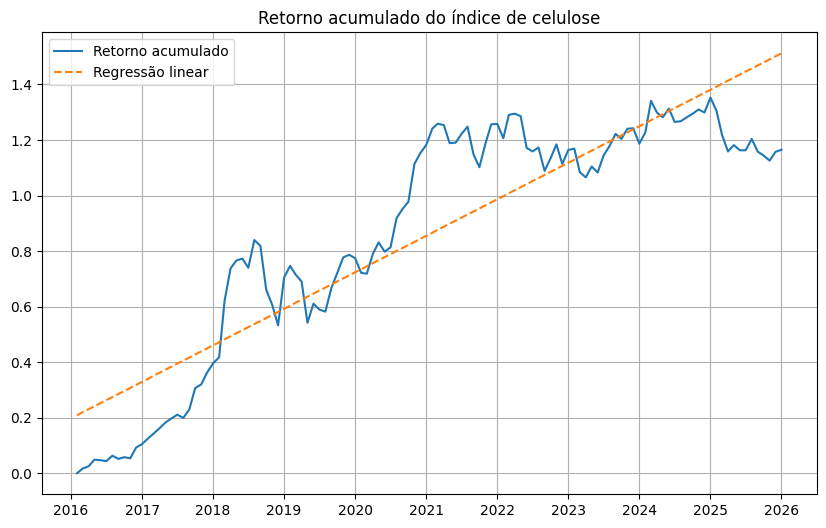

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(serie_indice.index, y, label="Retorno acumulado")
plt.plot(serie_indice.index, y_reg, linestyle="--", label="Regressão linear")
plt.title("Retorno acumulado do índice de celulose")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
df_retorno_indice = pd.DataFrame(retorno_indice, columns=["retorno_indice"])
df_retorno_indice

,retorno_indice
Date,
2016-02-01,0.000000
2016-03-01,0.016790
2016-04-01,0.008440
2016-05-01,0.023846
2016-06-01,-0.002105
...,...
2025-09-01,-0.045933
2025-10-01,-0.013640
2025-11-01,-0.018616


In [15]:
ativo = download('klbn11.sa', period='max', interval="1mo", auto_adjust=False)['Close'].pct_change(1).dropna()
ativo

[*********************100%***********************]  1 of 1 completed


Ticker,KLBN11.SA
Date,
2014-02-01,-0.064677
2014-03-01,0.003621
2014-04-01,0.005155
2014-05-01,-0.022222
2014-06-01,-0.029720
...,...
2025-09-01,-0.025392
2025-10-01,0.000000
2025-11-01,-0.016630


In [16]:
data1 = pd.concat([df_retorno_indice, ativo], axis=1).dropna()

data1

,retorno_indice,KLBN11.SA
Date,,
2016-02-01,0.000000,0.023810
2016-03-01,0.016790,-0.100000
2016-04-01,0.008440,-0.099225
2016-05-01,0.023846,0.041308
2016-06-01,-0.002105,-0.150413
...,...,...
2025-09-01,-0.045933,-0.025392
2025-10-01,-0.013640,0.000000
2025-11-01,-0.018616,-0.016630


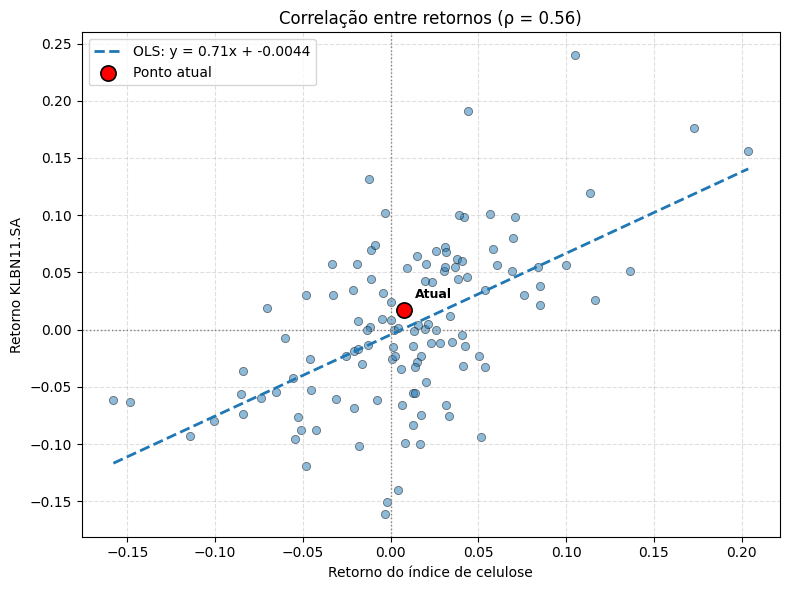

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = data1["retorno_indice"]
y = data1["KLBN11.SA"]


# Correlação
corr = x.corr(y)

# Regressão linear
coef = np.polyfit(x, y, 1)
x_reg = np.linspace(x.min(), x.max(), 100)
y_reg = coef[0] * x_reg + coef[1]

plt.figure(figsize=(8, 6))

# Scatter
plt.scatter(
    x, y,
    alpha=0.5,
    s=35,
    linewidth=0.6,
    edgecolor="black"
)

# Linha de regressão
plt.plot(
    x_reg, y_reg,
    linestyle="--",
    linewidth=2,
    label=f"OLS: y = {coef[0]:.2f}x + {coef[1]:.4f}"
)

# Último ponto (ponto atual)
x_atual = x.iloc[-1]
y_atual = y.iloc[-1]

# Ponto atual
plt.scatter(
    x_atual, y_atual,
    color="red",
    s=120,
    edgecolor="black",
    linewidth=1.2,
    zorder=5,
    label="Ponto atual"
)

# Anotação opcional
plt.annotate(
    "Atual",
    (x_atual, y_atual),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=9,
    weight="bold"
)

# Linhas de referência
plt.axhline(0, linewidth=1, linestyle=":", color="gray")
plt.axvline(0, linewidth=1, linestyle=":", color="gray")

plt.xlabel("Retorno do índice de celulose")
plt.ylabel("Retorno KLBN11.SA")
plt.title(f"Correlação entre retornos (ρ = {corr:.2f})")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
